In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
data_set = pd.read_csv("/content/drive/MyDrive/student scores.csv")

In [ ]:
data_set.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [ ]:
data_set.tail()

,Hours,Scores
20,2.7,30
21,4.8,54
22,3.8,35
23,6.9,76
24,7.8,86


In [ ]:
data_set.shape

(25, 2)

In [ ]:
data_set.columns

Index(['Hours', 'Scores'], dtype='object')

In [ ]:
data_set.dtypes

,0
Hours,float64
Scores,int64


In [ ]:
data_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   25 non-null     float64
 1   Scores  25 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 532.0 bytes


In [ ]:
data_set.describe()

,Hours,Scores
count,25.000000,25.000000
mean,5.012000,51.480000
std,2.525094,25.286887
min,1.100000,17.000000
25%,2.700000,30.000000
50%,4.800000,47.000000
75%,7.400000,75.000000
max,9.200000,95.000000


In [ ]:
X= data_set.iloc[:,:-1]  #separate i/d and dependent variables
Y= data_set.iloc[:,-1]

In [ ]:
print(X.head())

   Hours
0    2.5
1    5.1
2    3.2
3    8.5
4    3.5


In [ ]:
print(Y.head())

0    21
1    47
2    27
3    75
4    30
Name: Scores, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=1)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(17, 1)
(8, 1)


In [ ]:
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()
regressor.fit(X_train,Y_train)

LinearRegression()

In [ ]:
print("Intercept B0 = ",regressor.intercept_)
print("Coefficient B1 = ",regressor.coef_)

Intercept B0 =  -1.5123061161277889
Coefficient B1 =  [10.41075981]


In [ ]:
ynew = -1.5123061161277889 + 10.41075981 * 6
print("Score for 6 hours study = ",ynew)

Score for 6 hours study =  60.95225274387221


In [ ]:
a=[[6.0]]
ynew=regressor.predict(a)
print(ynew)

[60.95225275]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
ypred=regressor.predict(X_test)

In [ ]:
print(ypred)
print(Y_test)

[ 9.93952968 32.84320126 18.26813752 86.97915227 48.45934097 78.65054442
 61.99332873 75.52731648]
14    17
13    42
17    24
3     75
21    54
10    85
18    67
19    69
Name: Scores, dtype: int64


In [ ]:
# Training Accuracy
print("Training Accuracy = ",regressor.score(X_train,Y_train))

Training Accuracy =  0.9681980033905908


In [ ]:
# Testing Accuracy
print("Testing Accuracy = ",regressor.score(X_test,Y_test))

Testing Accuracy =  0.8933827573294114


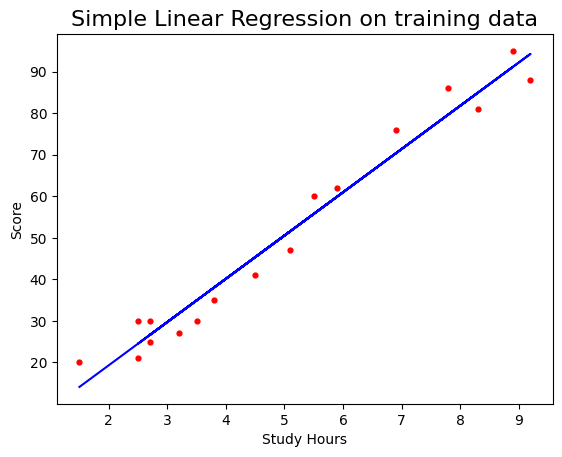

In [ ]:
plt.scatter(X_train,Y_train,color='red',s=12)
plt.plot(X_train,regressor.predict(X_train),color='blue')
plt.title("Simple Linear Regression on training data",size=16)
plt.xlabel("Study Hours")
plt.ylabel("Score")
plt.show()

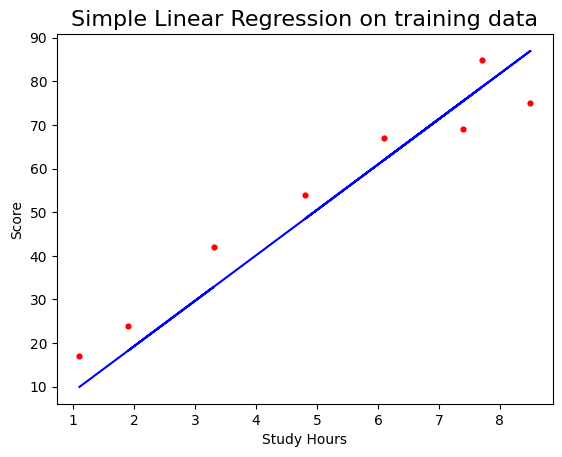

In [ ]:
plt.scatter(X_test,Y_test,color='red',s=12)
plt.plot(X_test,regressor.predict(X_test),color='blue')
plt.title("Simple Linear Regression on training data",size=16)
plt.xlabel("Study Hours")
plt.ylabel("Score")
plt.show()

In [ ]:
from sklearn.metrics import r2_score
r2_score(Y_test,ypred)

0.8933827573294114

In [ ]:
from sklearn.metrics import mean_squared_error
mean_squared_error(Y_test,ypred)

56.092330905646705

In [ ]:
from sklearn.metrics import median_absolute_error
median_absolute_error(Y_train,regressor.predict(X_train))

np.float64(4.336113030425771)